# Tesera vs BoardGameGeek: два сообщества, два топа

**Вопрос:** совпадают ли вкусы российского сообщества настольщиков (Tesera.ru) с мировым (BoardGameGeek)?

**Данные:** две выборки - топ-500 Tesera (по байесовскому рейтингу) и топ-500 по рейтингу BGG. Сбор - `collect.py`
(открытый API Tesera + HTML-страницы игр), BGG-поля Tesera хранит у себя вместе с идентификатором игры на BGG.
Узкие таблицы сведены в широкую (`make_wide.py`): одна строка - одна игра.

Страница с интерактивными графиками: https://viktor-vk.github.io/projects/tesera-bgg/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from csv_format import read_csv

pd.set_option('display.max_columns', 50)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})
TESERA, BGG, BOTH = '#2a9cc0', '#c47a22', '#8a66da'

## 1. Данные и фильтр

Сравниваем только игры, у которых достаточно оценок на обеих площадках: 20+ на Tesera и 100+ на BGG.
Нули в рейтингах на Tesera означают «нет данных» - в широкой таблице они уже заменены пропусками.

In [2]:
MIN_VOTES_TESERA, MIN_VOTES_BGG = 20, 100

w = read_csv('data/games_wide_top500.csv')
w['diff'] = w.tesera_avg_rating - w.bgg_avg_rating          # > 0: на Tesera оценка выше
w['in_t'] = w.rank_in_tesera_top.notna()
w['in_b'] = w.rank_in_bgg_top.notna()

f = w[(w.tesera_num_votes >= MIN_VOTES_TESERA) & (w.bgg_num_votes >= MIN_VOTES_BGG)].copy()
base = f[~f.is_addition]

print(f'Игр в двух топах: {len(w)}, в обоих сразу: {(w.in_t & w.in_b).sum()}, дополнений: {w.is_addition.sum()}')
print(f'В сравнении после фильтра: {len(f)} (базовых игр: {len(base)})')
w[['rank_in_tesera_top', 'rank_in_bgg_top', 'title', 'is_addition', 'tesera_year_published',
   'tesera_avg_rating', 'bgg_avg_rating', 'diff', 'tesera_num_votes', 'bgg_num_votes']].head()

Игр в двух топах: 756, в обоих сразу: 244, дополнений: 254
В сравнении после фильтра: 661 (базовых игр: 455)


,rank_in_tesera_top,rank_in_bgg_top,title,is_addition,tesera_year_published,tesera_avg_rating,bgg_avg_rating,diff,tesera_num_votes,bgg_num_votes
0,1.0,13.0,Звёздные войны: Восстание,False,2016,8.82,8.42,0.40,847.0,34966.0
1,2.0,12.0,The Castles of Burgundy: Special Edition,False,2023,8.99,9.15,-0.16,119.0,6193.0
2,3.0,174.0,Сумерки империи. Четвёртая редакция: Пророчест...,True,2020,8.95,9.19,-0.24,127.0,2995.0
3,4.0,196.0,Forbidden Stars,True,2015,8.77,7.98,0.79,588.0,9742.0
4,5.0,30.0,Рыцарь-маг. Полное издание,True,2018,8.75,8.85,-0.10,432.0,7865.0


## 2. Эффект отбора: «свой» топ всегда щедрее

Если смотреть только на топ Tesera, кажется, что на Tesera оценивают выше. Проверяем то же на зеркальной
выборке - топе BGG.

In [3]:
def summary(s):
    return pd.Series({'игр': len(s), 'средняя разница': round(s['diff'].mean(), 3),
                      'медиана': round(s['diff'].median(), 3), 'доля Tesera выше': round((s['diff'] > 0).mean(), 3), 'p (t-тест)': f"{stats.ttest_1samp(s['diff'], 0).pvalue:.1g}"})

pd.DataFrame({'топ Tesera': summary(f[f.in_t]), 'топ BGG': summary(f[f.in_b]), 'обе выборки': summary(f)}).T.round(3)

,игр,средняя разница,медиана,доля Tesera выше,p (t-тест)
топ Tesera,443,0.211,0.18,0.781,3e-40
топ BGG,459,0.012,0.05,0.549,0.4
обе выборки,661,0.102,0.1,0.638,4e-13


Корреляция Спирмена оценок: 0.69


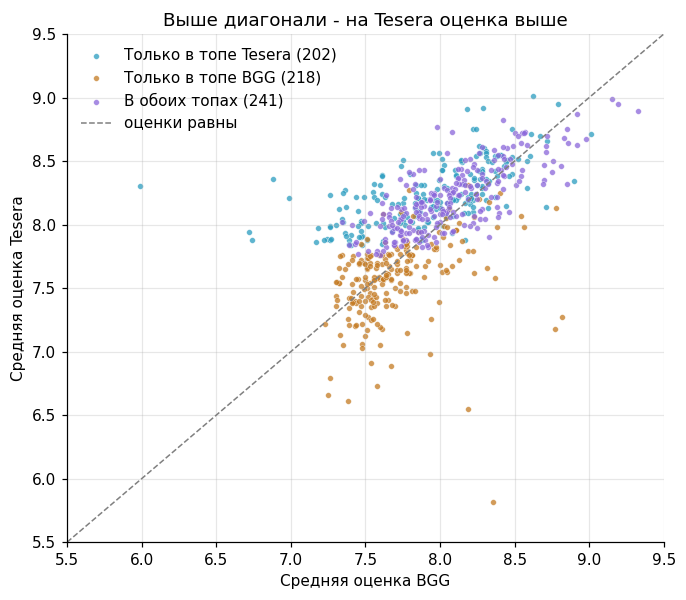

In [4]:
rho = stats.spearmanr(f.tesera_avg_rating, f.bgg_avg_rating)
print(f'Корреляция Спирмена оценок: {rho.correlation:.2f}')

fig, ax = plt.subplots(figsize=(7, 6))
groups = [('Только в топе Tesera', f.in_t & ~f.in_b, TESERA), ('Только в топе BGG', f.in_b & ~f.in_t, BGG),
          ('В обоих топах', f.in_t & f.in_b, BOTH)]
for name, mask, color in groups:
    ax.scatter(f.loc[mask, 'bgg_avg_rating'], f.loc[mask, 'tesera_avg_rating'], s=14, alpha=0.75,
               color=color, label=f'{name} ({mask.sum()})', edgecolor='white', linewidth=0.3)
lo, hi = 5.5, 9.5
ax.plot([lo, hi], [lo, hi], ls='--', color='grey', lw=1, label='оценки равны')
ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel='Средняя оценка BGG', ylabel='Средняя оценка Tesera',
       title='Выше диагонали - на Tesera оценка выше')
ax.legend(loc='upper left', frameon=False)
plt.show()

**Вывод.** В топе Tesera разница +0,21 и почти у 80% игр оценка на Tesera выше. В топе BGG разницы практически нет
(+0,01, p = 0,43). В топ площадки попадают игры, которым на ней повезло с оценками, поэтому сравнение по одному
топу даёт ложный вывод. Два топ-500 пересекаются меньше чем наполовину, а оценки связаны лишь умеренно.

## 3. Год выпуска: «золотая эпоха» 2000-2014

,mean,median,count
period,,,
до 2000,-0.003,0.015,20
2000-2009,0.251,0.250,43
2010-2014,0.303,0.260,81
2015-2019,0.103,0.105,164
2020-2022,-0.013,0.060,104
2023+,-0.020,-0.020,37


топ Tesera: связь года выпуска и разницы rho = -0.42, p = 4e-20
топ BGG: связь года выпуска и разницы rho = -0.24, p = 2e-07


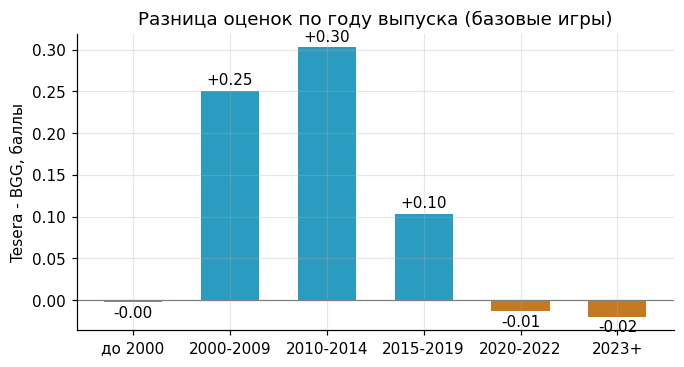

In [5]:
bins = [0, 1999, 2009, 2014, 2019, 2022, 2100]
labels = ['до 2000', '2000-2009', '2010-2014', '2015-2019', '2020-2022', '2023+']
by_period = (base.assign(period=pd.cut(base.tesera_year_published, bins, labels=labels))
             .groupby('period', observed=True)['diff'].agg(['mean', 'median', 'count']))
display(by_period.round(3))

for name, s in [('топ Tesera', f[f.in_t]), ('топ BGG', f[f.in_b])]:
    r = stats.spearmanr(s.tesera_year_published, s['diff'], nan_policy='omit')
    print(f'{name}: связь года выпуска и разницы rho = {r.correlation:.2f}, p = {r.pvalue:.1g}')

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [TESERA if v >= 0 else BGG for v in by_period['mean']]
bars = ax.bar(by_period.index.astype(str), by_period['mean'], color=colors, width=0.6)
ax.bar_label(bars, labels=[f'{v:+.2f}' for v in by_period['mean']], padding=2)
ax.axhline(0, color='grey', lw=0.8)
ax.set(ylabel='Tesera - BGG, баллы', title='Разница оценок по году выпуска (базовые игры)')
plt.show()

**Вывод.** Игры 2000-2014 годов на Tesera оценивают на 0,25-0,30 выше, чем на BGG, а по новинкам 2020+ вкусы
совпадают. Эффект есть в обеих выборках. Гипотезы: хиты тех лет пришли в Россию позже, с локализацией, и
воспринимались как новинки; на BGG оценки старых игр со временем проседают на фоне потока новых.

## 4. Жанры

,mean,count
genre,,
Компанейские,-0.102,19
Приключения,0.058,103
Карты,0.076,86
Азартные,0.079,17
Логические,0.101,25
Экономика,0.142,168
Война,0.230,113


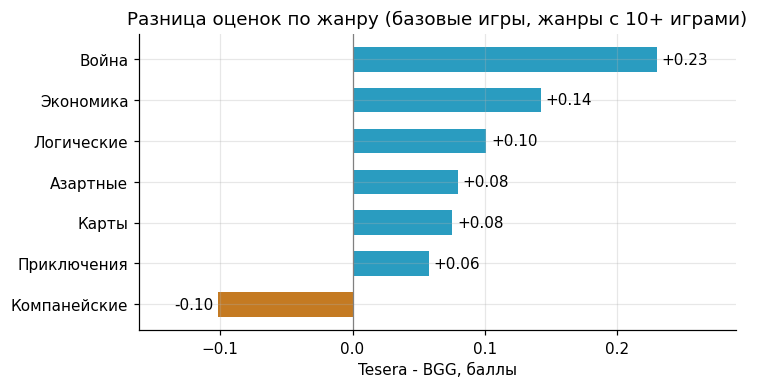

In [6]:
ge = base.assign(genre=base.tesera_genre.fillna('').str.split(', ')).explode('genre')
ge = ge[ge.genre != '']
by_genre = ge.groupby('genre')['diff'].agg(['mean', 'count']).query('count >= 10').sort_values('mean')
display(by_genre.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [TESERA if v >= 0 else BGG for v in by_genre['mean']]
bars = ax.barh(by_genre.index, by_genre['mean'], color=colors, height=0.6)
ax.bar_label(bars, labels=[f'{v:+.2f}' for v in by_genre['mean']], padding=3)
ax.axvline(0, color='grey', lw=0.8)
ax.margins(x=0.18)
ax.set(xlabel='Tesera - BGG, баллы', title='Разница оценок по жанру (базовые игры, жанры с 10+ играми)')
plt.show()

**Вывод.** Относительно BGG на Tesera выше ценят военные (+0,23) и экономические (+0,14) игры, ниже - компанейские
(-0,10). Аудитория Tesera - увлечённые игроки, которым ближе «тяжёлые» стратегии.

## 5. Дополнения

In [7]:
rows = {}
for name, s in [('топ Tesera', f[f.in_t]), ('топ BGG', f[f.in_b])]:
    b, a = s[~s.is_addition]['diff'], s[s.is_addition]['diff']
    rows[name] = {'базовые: разница': round(b.mean(), 3), 'дополнения: разница': round(a.mean(), 3), 'базовых': len(b),
                  'дополнений': len(a), 'p (Манн-Уитни)': f'{stats.mannwhitneyu(b, a).pvalue:.1g}'}
pd.DataFrame(rows).T.round(3)

,базовые: разница,дополнения: разница,базовых,дополнений,p (Манн-Уитни)
топ Tesera,0.26,0.132,273,170,7e-06
топ BGG,0.026,-0.034,350,109,0.003


**Вывод.** В обеих выборках дополнения получают на Tesera относительно более низкие оценки, чем базовые игры.
Гипотеза: на BGG дополнения оценивают в основном преданные фанаты базовой игры.

## 6. Дополнительно: как связаны суб-рейтинги Tesera

У Tesera четыре суб-рейтинга, и итоговая оценка - их среднее (проверка ниже). Поэтому корреляция суб-рейтинга с итогом
завышена по построению; смотрим связь суб-рейтингов между собой.

In [8]:
sub = {'tesera_gameplay': 'геймплей', 'tesera_depth': 'глубина',
       'tesera_originality': 'оригинальность', 'tesera_implementation': 'реализация'}
s = f.dropna(subset=list(sub))
mean4 = s[list(sub)].mean(axis=1)
print(f'Итог = среднее четырёх суб-рейтингов (±0,01): {((mean4 - s.tesera_avg_rating).abs() <= 0.0101).mean():.1%} игр')

display(s[list(sub)].rename(columns=sub).corr(method='spearman').round(2))
pd.DataFrame({name: {'средний балл': round(s[col].mean(), 2),
                     'rho со средним трёх остальных': round(stats.spearmanr(
                         s[col], s[[c for c in sub if c != col]].mean(axis=1)).correlation, 2)}
              for col, name in sub.items()}).T

Итог = среднее четырёх суб-рейтингов (±0,01): 99.5% игр


,геймплей,глубина,оригинальность,реализация
геймплей,1.00,0.77,0.65,0.70
глубина,0.77,1.00,0.72,0.53
оригинальность,0.65,0.72,1.00,0.54
реализация,0.70,0.53,0.54,1.00


,средний балл,rho со средним трёх остальных
геймплей,8.10,0.83
глубина,7.80,0.77
оригинальность,7.91,0.73
реализация,8.21,0.64


**Вывод.** Суб-рейтинги заметно связаны между собой (попарно rho 0,53-0,77): высокий балл по одному критерию обычно
тянет за собой и остальные. Сильнее всего с остальными согласован геймплей, слабее всего - реализация (компоненты и
оформление): её оценивают отдельно от самой игры, и средний балл у неё самый высокий.

## 7. Взгляд издателя: Hobby World

Какие издатели чаще всего встречаются в двух топах и где у изданий Hobby World самый высокий спрос на барахолке
Tesera (сколько людей хотят купить игру на одного продающего).

In [9]:
pub = w.assign(p=w.tesera_publisher.fillna('').str.split(', ')).explode('p')
display(pub[pub.p != ''].p.value_counts().head(6).rename('игр в двух топах').to_frame())

w['buy_per_sell'] = w.tesera_buying_now / w.tesera_selling_now.clip(lower=1)
hw = w[w.tesera_publisher.fillna('').str.contains('Hobby World') & (w.tesera_owners >= 300)]
print(f'Медиана «хотят купить / продают» по всей выборке: {w.buy_per_sell.median():.1f}')
(hw.sort_values('buy_per_sell', ascending=False)
   [['title', 'is_addition', 'tesera_owners', 'tesera_buying_now', 'tesera_selling_now', 'buy_per_sell']]
   .head(8).round(1))

,игр в двух топах
p,
Hobby World,126
Fantasy Flight Games,104
Crowd Games,102
Лавка игр,71
GaGa Games,61
Rio Grande Games,34


Медиана «хотят купить / продают» по всей выборке: 4.0


,title,is_addition,tesera_owners,tesera_buying_now,tesera_selling_now,buy_per_sell
274,Ктулху: Смерть может умереть. Второй сезон,True,364,22.0,1.0,22.0
173,Ужас Аркхэма. Ужас Инсмута,True,404,64.0,3.0,21.3
47,Древний ужас. Хребты безумия,True,1213,61.0,3.0,20.3
402,Брюгге,False,1066,138.0,7.0,19.7
63,Замки Бургундии,False,1724,274.0,15.0,18.3
51,Ark Nova,False,652,86.0,5.0,17.2
59,Descent: Тень Нерекхола,True,452,49.0,3.0,16.3
481,Восходящее солнце: Вторжение Династии,False,312,16.0,1.0,16.0


**Как читать.** Это накопленные объявления, а не спрос на сегодня: показатель годится для сравнения игр между собой
и как повод проверить допечатку, но не заменяет данных о продажах и остатках.

## Итоги и ограничения

1. «На Tesera оценивают выше» - в основном эффект отбора: в топе BGG разницы нет.
2. Игры 2000-2014 годов на Tesera ценят выше, чем в мире; по новинкам вкусы совпадают.
3. Tesera выше оценивает военные и экономические игры, ниже - компанейские.
4. Дополнения на Tesera оценивают сдержаннее.

Ограничения: обе выборки - топы, а не вся база; дата синхронизации BGG-полей на Tesera неизвестна; жанры и издатели
заполнены не у всех игр; дополнения определены по флагу Tesera, который помечает дополнениями и часть базовых игр,
но при проверке по связям между играми вывод про дополнения сохраняется; корреляции не доказывают причин.